# Análisis Estadístico sobre KDE

Este notebook calcula estadísticas descriptivas a partir de la estimación de densidad por kernel (KDE) aplicada a los datos de microbiota.

**Secciones:**
1. Carga de datos y preparación KDE
2. Medidas de tendencia central
3. Área bajo la curva KDE
4. Percentil de corte (densidad < 0.00001)
5. Cuartiles y percentiles (con reporte especial de Q10 y Q90)
6. Desigualdad de Chebyshev

## 0) Carga del DataFrame

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
import warnings
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity
from scipy.integrate import quad


In [2]:
FILE_PATH = r"C:\Users\josep\Documents\Proyectos\Proyectos_Python\Clustering_Microbiota\Datos\otu_data_converted.csv"   # <<< MODIFÍCALA AQUÍ

def load_dataframe_from_path(path):
    """
    Carga un DataFrame completo desde un archivo .csv o .otus.
    No filtra columnas.
    Retorna el DataFrame tal cual está en el archivo.
    """
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"No existe el archivo: {path}")

    ext = path.suffix.lower()

    if ext == ".csv":
        df = pd.read_csv(path, delimiter=",")
    elif ext == ".otus":
        df = pd.read_csv(path, sep="\t")  # Formato típico OTU
    else:
        raise ValueError(f"Formato no soportado: {ext}. Usa .csv o .otus")

    return df

df = load_dataframe_from_path(FILE_PATH)
print(f"Archivo cargado: {FILE_PATH}")
print(f"Shape del DataFrame: {df.shape}")
print(f"Columnas: {df.columns.tolist()[:10]}{' ...' if len(df.columns) > 10 else ''}")
df.head(5)

Archivo cargado: C:\Users\josep\Documents\Proyectos\Proyectos_Python\Clustering_Microbiota\Datos\otu_data_converted.csv
Shape del DataFrame: (441, 4739)
Columnas: ['ID', 'Otu00001', 'Otu00002', 'Otu00003', 'Otu00004', 'Otu00005', 'Otu00006', 'Otu00007', 'Otu00008', 'Otu00009'] ...


,ID,Otu00001,Otu00002,Otu00003,Otu00004,Otu00005,Otu00006,Otu00007,Otu00008,Otu00009,...,Otu04757,Otu04758,Otu04759,Otu04760,Otu04761,Otu04762,Otu04763,Otu04764,Otu04765,Otu04766
0,MI_001_H,354,817,50,31,448,547,727,353,2,...,0,0,0,0,0,0,0,0,0,0
1,MI_002_H,168,9,131,3005,68,10187,570,2006,104,...,0,0,0,0,0,0,0,0,0,0
2,MI_003_H,19,174,6211,79,1063,0,6077,1852,1471,...,0,0,0,0,0,0,0,0,0,0
3,MI_004_H,264,1816,159,16,110,4,12,206,0,...,0,0,0,0,0,0,0,0,0,0
4,MI_005_H,0,2,0,12,598,39,0,0,1,...,0,0,0,0,0,0,0,0,0,0


## 1) Preparación de datos y KDE

Mismo bloque que el notebook original. Ajusta los parámetros en la sección 0.

## 0.5) Selección del Ancho de Banda (Bandwidth)

Identifica el mejor `bw_method` antes de calcular el KDE.

- **`"auto"`** → Cross-validation de log-verosimilitud sobre una malla de bandwidths.
- **`"scott"` / `"silverman"`** → Reglas automáticas clásicas.
- **Número fijo** → Usar directamente como factor (ej. `0.3`).

Al final de la celda se imprime el valor recomendado para copiar en el parámetro `bw_method` del bloque KDE.

Datos: N = 105,420  |  std = 895.1  |  min = 1  |  max = 6.071e+04
Scott     : factor = 0.09895  |  bw = 88.57
Silverman : factor = 0.10481  |  bw = 93.81

CV con muestra de 10,000 puntos de 105,420 totales.
Malla bw: [4.428, 885.7]  (50 puntos, log)
Ejecutando 5-fold CV... (puede tardar unos segundos)

CV completado.
  Mejor bw (unidades de datos) : 334.685
  → factor para gaussian_kde   : 0.37392

  RECOMENDACIÓN
  bw_method = 0.37392
  Fuente    : Cross-validation (log-verosimilitud)
  → Copia este valor en bw_method del bloque KDE


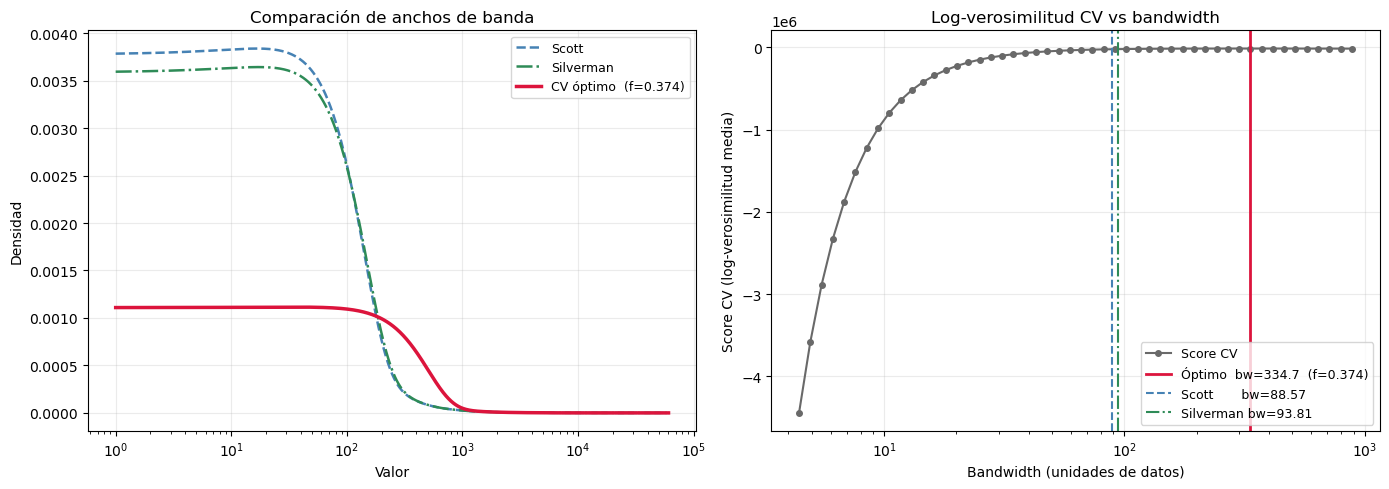

In [3]:
# =========================================
# SELECCIÓN DE ANCHO DE BANDA ÓPTIMO
#   Ejecutar antes del bloque KDE principal.
#   Al final se imprime el valor recomendado de bw_method.
# =========================================

# -----------------------------
# Parámetros (ajusta aquí)
# -----------------------------
_bw_selector      = "auto"   # "auto" (cross-validation) | "scott" | "silverman" | número fijo (ej. 0.3)
_usar_solo_pos    = True     # True -> solo valores > 0 (debe coincidir con usar_solo_positivos del KDE)
_usar_log_x       = True     # True -> KDE en escala log (debe coincidir con usar_escala_log_x del KDE)

# Solo relevante cuando _bw_selector = "auto":
_n_muestra_cv     = 10000     # Máx. puntos para CV (None = todos; con millones de datos puede ser lento)
_n_grid_cv        = 50       # Nº de bandwidths a evaluar en la malla
_cv_folds         = 5        # K para K-fold cross-validation
_bw_malla_log     = True     # True -> evaluar malla de bw en escala log (recomendado)
_bw_rango         = (0.05, 10.0)  # Multiplicadores sobre bw de Scott para los extremos de la malla

_mostrar_grafico  = True     # Mostrar gráfico comparativo

# ============================================================
# Preparar datos (misma lógica que el bloque KDE)
# ============================================================


_df_num_bw  = df.select_dtypes(include=[np.number])
_vals_bw    = _df_num_bw.to_numpy(dtype=float).ravel()
_vals_bw    = _vals_bw[np.isfinite(_vals_bw)]
_vals_pos   = _vals_bw[_vals_bw > 0]

if _usar_log_x:
    _usar_solo_pos = True

_data_bw = _vals_pos if _usar_solo_pos else _vals_bw

if len(_data_bw) == 0:
    raise ValueError("No hay datos con la selección actual.")

_n   = len(_data_bw)
_std = float(np.std(_data_bw, ddof=1))

# ============================================================
# Bandwidths de referencia: Scott y Silverman
# ============================================================
_kde_scott = gaussian_kde(_data_bw, bw_method="scott")
_kde_silv  = gaussian_kde(_data_bw, bw_method="silverman")

_bw_scott_abs     = float(_kde_scott.factor * _std)   # en unidades de los datos
_bw_silverman_abs = float(_kde_silv.factor  * _std)

print(f"Datos: N = {_n:,}  |  std = {_std:.4g}  |  min = {_data_bw.min():.4g}  |  max = {_data_bw.max():.4g}")
print(f"Scott     : factor = {_kde_scott.factor:.5f}  |  bw = {_bw_scott_abs:.4g}")
print(f"Silverman : factor = {_kde_silv.factor:.5f}  |  bw = {_bw_silverman_abs:.4g}")

# ============================================================
# Cross-validation (solo si _bw_selector = "auto")
# ============================================================
_bw_opt_factor = None
_bw_opt_abs    = None
_cv_scores     = None
_bw_grid_cv    = None

if _bw_selector == "auto":
    # Submuestreo para acelerar CV
    rng_bw = np.random.default_rng(42)
    if _n_muestra_cv is not None and _n > _n_muestra_cv:
        _idx_cv  = rng_bw.choice(_n, _n_muestra_cv, replace=False)
        _data_cv = _data_bw[_idx_cv]
        print(f"\nCV con muestra de {len(_data_cv):,} puntos de {_n:,} totales.")
    else:
        _data_cv = _data_bw
        print(f"\nCV con todos los {_n:,} puntos.")

    # Malla de bandwidths (en unidades de datos)
    _bw_min_cv = _bw_scott_abs * _bw_rango[0]
    _bw_max_cv = _bw_scott_abs * _bw_rango[1]
    if _bw_malla_log:
        _bw_grid_cv = np.logspace(np.log10(_bw_min_cv), np.log10(_bw_max_cv), _n_grid_cv)
    else:
        _bw_grid_cv = np.linspace(_bw_min_cv, _bw_max_cv, _n_grid_cv)

    print(f"Malla bw: [{_bw_min_cv:.4g}, {_bw_max_cv:.4g}]  ({_n_grid_cv} puntos, {'log' if _bw_malla_log else 'lineal'})")
    print(f"Ejecutando {_cv_folds}-fold CV... (puede tardar unos segundos)")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        _gs = GridSearchCV(
            KernelDensity(kernel="gaussian"),
            param_grid={"bandwidth": _bw_grid_cv},
            cv=_cv_folds,
            n_jobs=-1,
            return_train_score=False
        )
        _gs.fit(_data_cv.reshape(-1, 1))

    _bw_opt_abs    = float(_gs.best_params_["bandwidth"])
    _bw_opt_factor = _bw_opt_abs / _std
    _cv_scores     = _gs.cv_results_["mean_test_score"]

    print(f"\nCV completado.")
    print(f"  Mejor bw (unidades de datos) : {_bw_opt_abs:.6g}")
    print(f"  → factor para gaussian_kde   : {_bw_opt_factor:.5f}")

# ============================================================
# Decisión final: valor recomendado de bw_method
# ============================================================
if isinstance(_bw_selector, (int, float)):
    _bw_recomendado = float(_bw_selector)
    _bw_fuente      = f"fijo ({_bw_selector})"
elif _bw_selector == "scott":
    _bw_recomendado = "scott"
    _bw_fuente      = "Scott (automático)"
elif _bw_selector == "silverman":
    _bw_recomendado = "silverman"
    _bw_fuente      = "Silverman (automático)"
else:  # "auto"
    _bw_recomendado = round(_bw_opt_factor, 5)
    _bw_fuente      = "Cross-validation (log-verosimilitud)"

print()
print("=" * 60)
print(f"  RECOMENDACIÓN")
print(f"  bw_method = {repr(_bw_recomendado)}")
print(f"  Fuente    : {_bw_fuente}")
print("=" * 60)
print("  → Copia este valor en bw_method del bloque KDE")

# ============================================================
# Visualización comparativa
# ============================================================
if _mostrar_grafico:
    _x_vis = (
        np.logspace(np.log10(_data_bw.min()), np.log10(_data_bw.max()), 3000)
        if _usar_log_x
        else np.linspace(_data_bw.min(), _data_bw.max(), 3000)
    )

    _metodos_vis = [
        ("Scott",     "scott",     "steelblue", "--", 1.8),
        ("Silverman", "silverman", "seagreen",  "-.", 1.8),
    ]
    if _bw_opt_factor is not None:
        _metodos_vis.append(
            (f"CV óptimo  (f={_bw_opt_factor:.3f})", _bw_opt_factor, "crimson", "-", 2.5)
        )

    n_panels = 2 if (_bw_selector == "auto") else 1
    fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 5))
    if n_panels == 1:
        axes = [axes]

    # Panel izquierdo: KDE superpuestos
    ax_kde = axes[0]
    for label, method, color, ls, lw in _metodos_vis:
        _kde_tmp = gaussian_kde(_data_bw, bw_method=method)
        _y_tmp   = _kde_tmp(_x_vis)
        ax_kde.plot(_x_vis, _y_tmp, color=color, linestyle=ls, linewidth=lw, label=label)

    if _usar_log_x:
        ax_kde.set_xscale("log")
    ax_kde.set_title("Comparación de anchos de banda")
    ax_kde.set_xlabel("Valor")
    ax_kde.set_ylabel("Densidad")
    ax_kde.legend(fontsize=9)
    ax_kde.grid(True, alpha=0.25)

    # Panel derecho: curva CV (solo si se ejecutó CV)
    if _bw_selector == "auto":
        ax_cv = axes[1]
        ax_cv.plot(_bw_grid_cv, _cv_scores, "o-", color="dimgray",
                   markersize=4, linewidth=1.5, label="Score CV")

        ax_cv.axvline(_bw_opt_abs,    color="crimson",   linestyle="-",  linewidth=2,
                      label=f"Óptimo  bw={_bw_opt_abs:.4g}  (f={_bw_opt_factor:.3f})")
        ax_cv.axvline(_bw_scott_abs,  color="steelblue", linestyle="--", linewidth=1.5,
                      label=f"Scott       bw={_bw_scott_abs:.4g}")
        ax_cv.axvline(_bw_silverman_abs, color="seagreen", linestyle="-.", linewidth=1.5,
                      label=f"Silverman bw={_bw_silverman_abs:.4g}")

        if _bw_malla_log:
            ax_cv.set_xscale("log")
        ax_cv.set_title("Log-verosimilitud CV vs bandwidth")
        ax_cv.set_xlabel("Bandwidth (unidades de datos)")
        ax_cv.set_ylabel("Score CV (log-verosimilitud media)")
        ax_cv.legend(fontsize=9)
        ax_cv.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()

KDE sobre positivos los datos
N = 105420, min=1, max=6.071e+04
Parámetros: bw_method=scott, cut=0, xscale=log


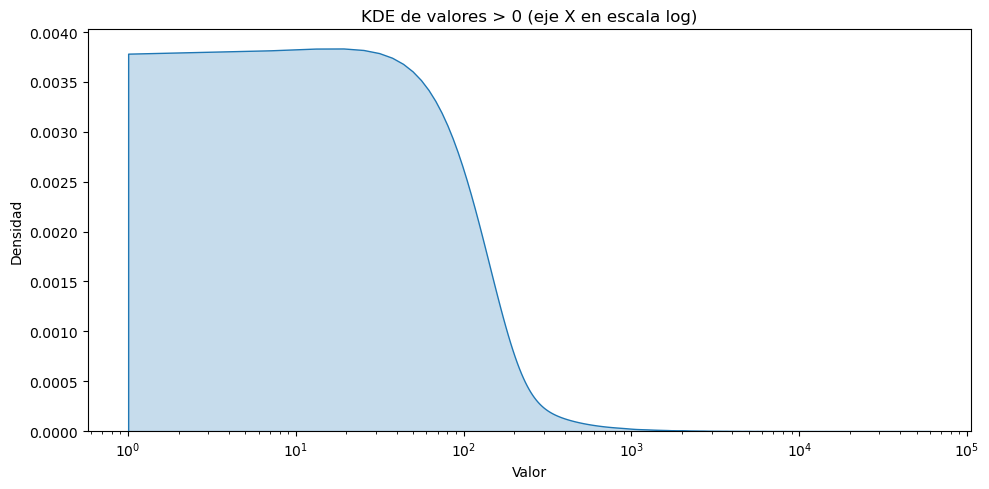

In [4]:
# =========================================
# KDE (Kernel Density Estimation) sobre df
#   - Permite: todos vs positivos
#   - Permite: eje X en escala lineal o log
#   - SIN muestreo
# =========================================

# -----------------------------
# 0) Parámetros (ajusta aquí)
# -----------------------------
usar_solo_positivos = True      # True -> solo X>0 ; False -> todos (incluye ceros)
usar_escala_log_x   = True      # True -> eje X log (requiere X>0)
bw_method = "scott"             # "scott", "silverman" o número (ej. 0.3)
cut = 0                         # evita extender fuera del rango
figsize = (10, 5)

# -----------------------------
# 1) Preparar datos desde DataFrame df
# -----------------------------
df_num = df.select_dtypes(include=[np.number])

if df_num.empty:
    raise ValueError("El DataFrame no tiene columnas numéricas para KDE.")

valores = df_num.to_numpy(dtype=float).ravel()
valores = valores[np.isfinite(valores)]

valores_pos = valores[valores > 0]

if usar_escala_log_x:
    usar_solo_positivos = True

data_kde = valores_pos if usar_solo_positivos else valores

if len(data_kde) == 0:
    raise ValueError("No hay datos para KDE con la selección actual.")

print(f"KDE sobre {'positivos' if usar_solo_positivos else 'todos'} los datos")
print(f"N = {len(data_kde)}, min={data_kde.min():.4g}, max={data_kde.max():.4g}")
print(f"Parámetros: bw_method={bw_method}, cut={cut}, xscale={'log' if usar_escala_log_x else 'linear'}")

# -----------------------------
# 2) KDE numérico (scipy) — base para todos los cálculos
# -----------------------------
kde_obj = gaussian_kde(data_kde, bw_method=bw_method)

# Malla de evaluación (log-espaciada si escala log, lineal si no)
if usar_escala_log_x:
    x_grid = np.logspace(np.log10(data_kde.min()), np.log10(data_kde.max()), 10000)
else:
    x_grid = np.linspace(data_kde.min(), data_kde.max(), 10000)

y_grid = kde_obj(x_grid)  # densidad evaluada en la malla

# -----------------------------
# 3) Gráfico KDE (seaborn)
# -----------------------------
fig, ax = plt.subplots(figsize=figsize)

sns.kdeplot(
    data_kde,
    fill=True,
    bw_method=bw_method,
    gridsize=10000,
    cut=cut,
    ax=ax
)

if usar_escala_log_x:
    ax.set_xscale("log")

titulo = "KDE de valores > 0" if usar_solo_positivos else "KDE de todos los valores"
if usar_escala_log_x:
    titulo += " (eje X en escala log)"

ax.set_title(titulo)
ax.set_xlabel("Valor")
ax.set_ylabel("Densidad")
plt.tight_layout()
plt.show()

## 2) Medidas de Tendencia Central

- **Media**: promedio aritmético de los datos.
- **Mediana**: valor que divide la distribución al 50%.
- **Moda KDE**: punto de máxima densidad estimada por el KDE.

  MEDIDAS DE TENDENCIA CENTRAL
  Media      : 139.921
  Mediana    : 8
  Moda (KDE) : 16.5721


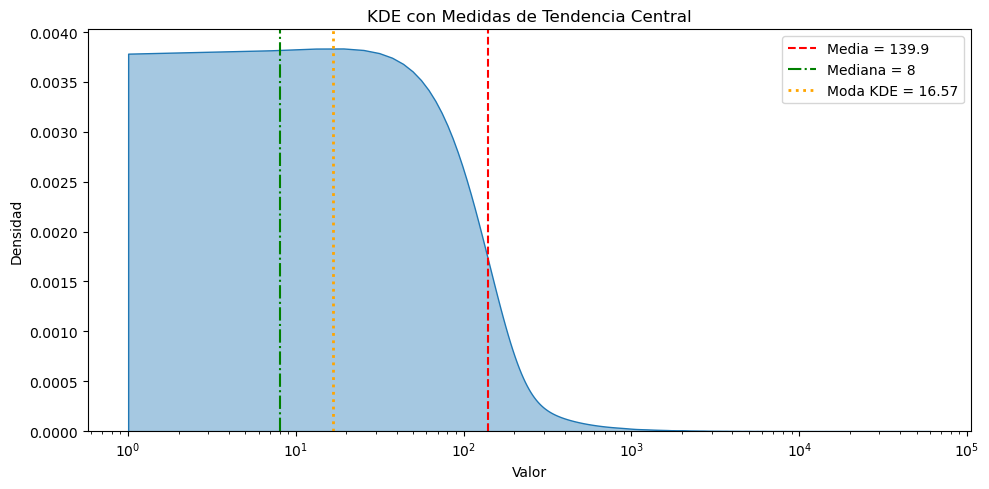

In [5]:
# =========================================
# 2) Medidas de Tendencia Central
# =========================================

media    = float(np.mean(data_kde))
mediana  = float(np.median(data_kde))
moda_kde = float(x_grid[np.argmax(y_grid)])   # punto de máxima densidad en el KDE

print("=" * 45)
print("  MEDIDAS DE TENDENCIA CENTRAL")
print("=" * 45)
print(f"  Media      : {media:.6g}")
print(f"  Mediana    : {mediana:.6g}")
print(f"  Moda (KDE) : {moda_kde:.6g}")
print("=" * 45)

# Visualización con líneas verticales sobre el KDE
fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(
    data_kde,
    fill=True,
    bw_method=bw_method,
    gridsize=10000,
    cut=cut,
    ax=ax,
    alpha=0.4,
    label="_nolegend_"
)

ax.axvline(media,    color="red",    linestyle="--", linewidth=1.5, label=f"Media = {media:.4g}")
ax.axvline(mediana,  color="green",  linestyle="-.", linewidth=1.5, label=f"Mediana = {mediana:.4g}")
ax.axvline(moda_kde, color="orange", linestyle=":",  linewidth=2,   label=f"Moda KDE = {moda_kde:.4g}")

if usar_escala_log_x:
    ax.set_xscale("log")

ax.set_title("KDE con Medidas de Tendencia Central")
ax.set_xlabel("Valor")
ax.set_ylabel("Densidad")
ax.legend()
plt.tight_layout()
plt.show()

## 3) Área Bajo la Curva KDE

El KDE es una suma de gaussianas centradas en cada dato. Su soporte real se extiende más allá del rango `[min, max]` de los datos, por lo que integrar solo sobre ese rango pierde masa de las colas.

**Estrategia de corrección:**
- Se extiende la malla `N_TAILS` anchos de banda más allá de los datos en ambos extremos.
- Se usa `scipy.integrate.quad` para la integral exacta (puede integrar hasta ±∞).
- Se reporta el área capturada por la malla extendida y el área exacta.

C:\Users\josep\AppData\Local\Temp\ipykernel_20716\329069760.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_malla   = float(np.trapz(y_grid_ext, x_grid_ext))
C:\Users\josep\AppData\Local\Temp\ipykernel_20716\329069760.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_sin_colas = float(np.trapz(y_grid, x_grid))


  ÁREA BAJO LA CURVA KDE
  Ancho de banda (bw_std)      : 88.57
  Rango original               : [1, 6.071e+04]
  Rango extendido (±6·bw)     : [0.001, 6.124e+04]

  Área SIN extender colas      : 0.61946337  (pérdida = 38.05%)
  Área malla extendida         : 0.62324486  (pérdida = 37.68%)
  Área exacta (scipy.quad)     : 0.62324478  (error est. = 1.33e-08)

  Valor teórico esperado       : 1.00000000
  Desviación quad vs teórico   : 3.77e-01


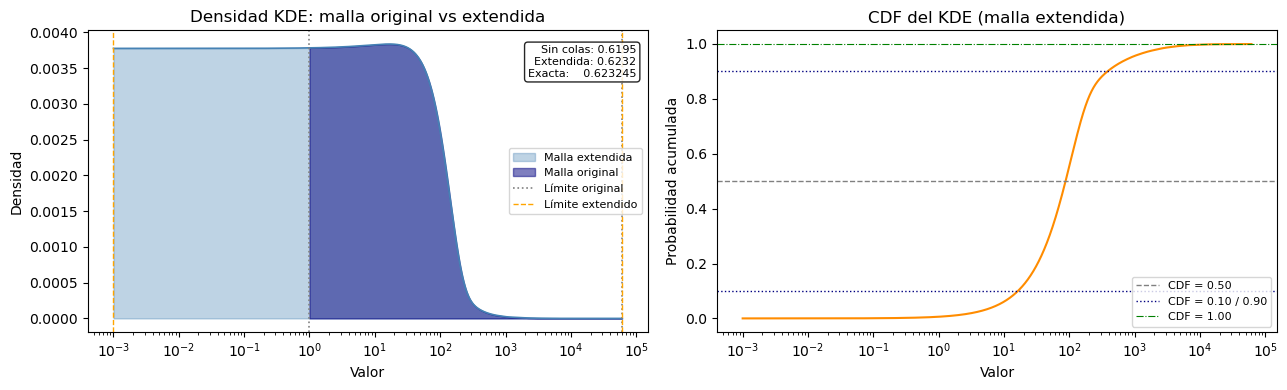

In [6]:
# =========================================
# 3) Área Bajo la Curva KDE
# =========================================

# -----------------------------
# A) Extender la malla para cubrir las colas
# -----------------------------
# El ancho de banda del KDE determina cuánto se extienden los kernels
# más allá del rango de los datos.
N_TAILS = 6   # número de anchos de banda a añadir en cada cola

bw_std = float(kde_obj.factor * np.std(data_kde, ddof=1))  # ancho de banda en unidades de x

x_lo_ext = data_kde.min() - N_TAILS * bw_std
x_hi_ext = data_kde.max() + N_TAILS * bw_std

# Si los datos son positivos con escala log, el límite inferior no puede ser ≤ 0
if usar_escala_log_x or usar_solo_positivos:
    x_lo_ext = max(x_lo_ext, data_kde.min() * 1e-3)  # mínimo: 0.1% del mínimo de los datos

# Malla extendida para visualización y CDF
if usar_escala_log_x:
    x_grid_ext = np.logspace(np.log10(x_lo_ext), np.log10(x_hi_ext), 20000)
else:
    x_grid_ext = np.linspace(x_lo_ext, x_hi_ext, 20000)

y_grid_ext = kde_obj(x_grid_ext)

# -----------------------------
# B) Área por trapecio (malla extendida) vs integral exacta (quad)
# -----------------------------
area_malla   = float(np.trapz(y_grid_ext, x_grid_ext))
area_exacta, area_err = quad(kde_obj, x_lo_ext, x_hi_ext, limit=300)

# Área original (sin extensión de colas) para mostrar la pérdida
area_sin_colas = float(np.trapz(y_grid, x_grid))

print("=" * 58)
print("  ÁREA BAJO LA CURVA KDE")
print("=" * 58)
print(f"  Ancho de banda (bw_std)      : {bw_std:.4g}")
print(f"  Rango original               : [{x_grid.min():.4g}, {x_grid.max():.4g}]")
print(f"  Rango extendido (±{N_TAILS}·bw)     : [{x_lo_ext:.4g}, {x_hi_ext:.4g}]")
print()
print(f"  Área SIN extender colas      : {area_sin_colas:.8f}  (pérdida = {1-area_sin_colas:.2%})")
print(f"  Área malla extendida         : {area_malla:.8f}  (pérdida = {1-area_malla:.2%})")
print(f"  Área exacta (scipy.quad)     : {area_exacta:.8f}  (error est. = {area_err:.2e})")
print()
print(f"  Valor teórico esperado       : 1.00000000")
print(f"  Desviación quad vs teórico   : {abs(1.0 - area_exacta):.2e}")
print("=" * 58)

# -----------------------------
# C) CDF del KDE (sobre malla extendida, sin normalización artificial)
# -----------------------------
dx_ext  = np.diff(x_grid_ext, prepend=x_grid_ext[0])
cdf_kde = np.cumsum(y_grid_ext * dx_ext)
# Normalizar usando el área exacta para que CDF(∞) = 1
cdf_kde = cdf_kde / area_exacta

# -----------------------------
# D) Visualización
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Izquierda: densidad — malla original vs extendida
axes[0].fill_between(x_grid_ext, y_grid_ext, alpha=0.35, color="steelblue", label="Malla extendida")
axes[0].fill_between(x_grid, y_grid, alpha=0.5, color="navy", label="Malla original")
axes[0].plot(x_grid_ext, y_grid_ext, linewidth=1.2, color="steelblue")

# Marcar los límites de extensión
axes[0].axvline(x_grid.min(), color="gray",   linestyle=":", linewidth=1.2, label=f"Límite original")
axes[0].axvline(x_grid.max(), color="gray",   linestyle=":", linewidth=1.2)
axes[0].axvline(x_lo_ext,     color="orange", linestyle="--", linewidth=1,  label=f"Límite extendido")
axes[0].axvline(x_hi_ext,     color="orange", linestyle="--", linewidth=1)

axes[0].text(0.98, 0.95,
             f"Sin colas: {area_sin_colas:.4f}\nExtendida: {area_malla:.4f}\nExacta:    {area_exacta:.6f}",
             ha="right", va="top", transform=axes[0].transAxes, fontsize=8,
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))

if usar_escala_log_x:
    axes[0].set_xscale("log")
axes[0].set_title("Densidad KDE: malla original vs extendida")
axes[0].set_xlabel("Valor")
axes[0].set_ylabel("Densidad")
axes[0].legend(fontsize=8)

# Derecha: CDF del KDE (malla extendida)
axes[1].plot(x_grid_ext, cdf_kde, linewidth=1.5, color="darkorange")
axes[1].axhline(0.5, color="gray",  linestyle="--", linewidth=1,   label="CDF = 0.50")
axes[1].axhline(0.1, color="navy",  linestyle=":",  linewidth=1,   label="CDF = 0.10 / 0.90")
axes[1].axhline(0.9, color="navy",  linestyle=":",  linewidth=1)
axes[1].axhline(1.0, color="green", linestyle="-.", linewidth=0.8, label="CDF = 1.00")

if usar_escala_log_x:
    axes[1].set_xscale("log")
axes[1].set_title("CDF del KDE (malla extendida)")
axes[1].set_xlabel("Valor")
axes[1].set_ylabel("Probabilidad acumulada")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5) Cuartiles y Percentiles

Cálculo empírico sobre `data_kde` con reporte especial de **Q10** y **Q90**.

  CUARTILES, PERCENTILES Y DECILES
Cuartiles / percentiles clave:
  Q10  (P10)  =  1  <<
  Q25  (P25)  =  2
  Q50  (P50)  =  8
  Q75  (P75)  =  38
  Q90  (P90)  =  189  <<
------------------------------------------------------------
Deciles:
  D1   (P10)  =  1
  D2   (P20)  =  2
  D3   (P30)  =  3
  D4   (P40)  =  5
  D5   (P50)  =  8
  D6   (P60)  =  13
  D7   (P70)  =  26
  D8   (P80)  =  58
  D9   (P90)  =  189
------------------------------------------------------------
  IQR (Q75 - Q25)              =  36
  Rango intercuartil (Q10–Q90) =  [1, 189]


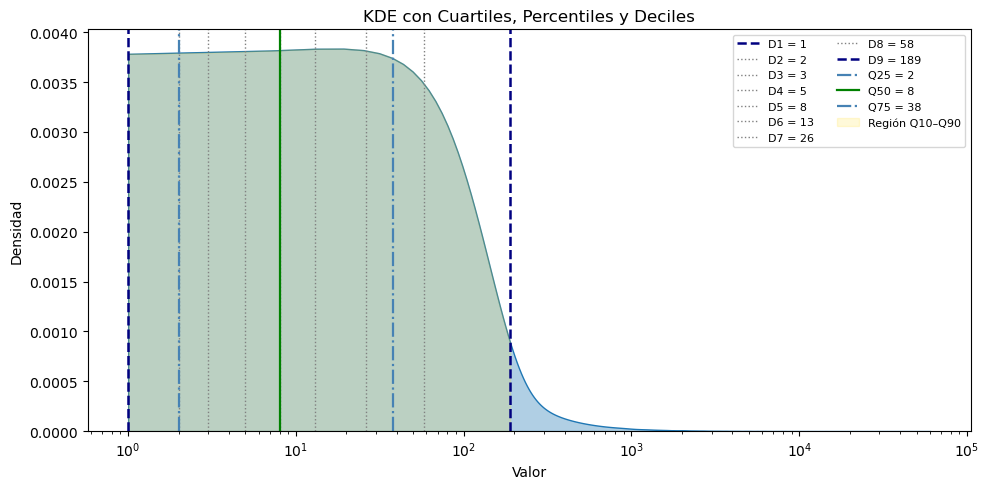

In [13]:
# =========================================
# 5) Cuartiles, Percentiles y Deciles
# =========================================

# Niveles de percentiles a calcular
niveles_deciles = list(range(10, 100, 10))   # 10,20,...,90
niveles_cuartiles = [25, 50, 75]
niveles_extra = [10, 90]  # para seguir destacando Q10 y Q90 si lo deseas

niveles = sorted(set(niveles_deciles + niveles_cuartiles + niveles_extra))
percentiles = np.percentile(data_kde, niveles)

# Guardar en diccionario para acceso cómodo
pct = dict(zip(niveles, percentiles))

# Cuartiles / percentiles clave
Q10 = pct[10]
Q25 = pct[25]
Q50 = pct[50]
Q75 = pct[75]
Q90 = pct[90]
IQR = Q75 - Q25

print("=" * 60)
print("  CUARTILES, PERCENTILES Y DECILES")
print("=" * 60)

print("Cuartiles / percentiles clave:")
for nivel in [10, 25, 50, 75, 90]:
    valor = pct[nivel]
    etiqueta = f"Q{nivel}"
    destaca = "  <<" if nivel in (10, 90) else ""
    print(f"  {etiqueta:<4} (P{nivel:02d})  =  {valor:.6g}{destaca}")

print("-" * 60)
print("Deciles:")
for i, nivel in enumerate(niveles_deciles, start=1):
    valor = pct[nivel]
    print(f"  D{i}   (P{nivel:02d})  =  {valor:.6g}")

print("-" * 60)
print(f"  IQR (Q75 - Q25)              =  {IQR:.6g}")
print(f"  Rango intercuartil (Q10–Q90) =  [{Q10:.4g}, {Q90:.4g}]")
print("=" * 60)

# =========================================
# Visualización
# =========================================
fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(
    data_kde, fill=True, bw_method=bw_method,
    gridsize=10000, cut=cut, ax=ax, alpha=0.35, label="_nolegend_"
)

# Dibujar deciles
for i, nivel in enumerate(niveles_deciles, start=1):
    valor = pct[nivel]

    # Destacar más D1 y D9
    if nivel in (10, 90):
        color = "navy"
        estilo = "--"
        lw = 1.8
    else:
        color = "gray"
        estilo = ":"
        lw = 1.0

    ax.axvline(
        valor, color=color, linestyle=estilo, linewidth=lw,
        label=f"D{i} = {valor:.4g}"
    )

# Dibujar cuartiles encima para destacarlos
colores_q = {25: "steelblue", 50: "green", 75: "steelblue"}
estilos_q = {25: "-.", 50: "-", 75: "-."}

for nivel in niveles_cuartiles:
    valor = pct[nivel]
    ax.axvline(
        valor, color=colores_q[nivel], linestyle=estilos_q[nivel],
        linewidth=1.6, label=f"Q{nivel} = {valor:.4g}"
    )

# Sombrear región Q10–Q90
mascara_rango = (x_grid >= Q10) & (x_grid <= Q90)
ax.fill_between(
    x_grid, y_grid, where=mascara_rango,
    alpha=0.15, color="gold", label="Región Q10–Q90"
)

if usar_escala_log_x:
    ax.set_xscale("log")

ax.set_title("KDE con Cuartiles, Percentiles y Deciles")
ax.set_xlabel("Valor")
ax.set_ylabel("Densidad")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 6) Desigualdad de Chebyshev

La desigualdad de Chebyshev establece que para **cualquier** distribución con media finita $\mu$ y varianza finita $\sigma^2$:

$$P(|X - \mu| \geq k\sigma) \leq \frac{1}{k^2} \quad \forall\, k > 1$$

Se compara la **cota teórica** $1/k^2$ contra la **proporción empírica** observada en los datos.

  DESIGUALDAD DE CHEBYSHEV
  media = 139.921  |  mediana = 8  |  sigma = 895.074  |  N = 105420
      k           media ± k*sigma     Cota 1/k²    Prop. empírica   Cumple?
---------------------------------------------------------------------------
    1.0            [-755.2, 1035]      1.000000          0.025877        SI
    1.5             [-1203, 1483]      0.444444          0.018365        SI
    2.0             [-1650, 1930]      0.250000          0.014020        SI
    2.5             [-2098, 2378]      0.160000          0.010928        SI
    3.0             [-2545, 2825]      0.111111          0.008822        SI
    4.0             [-3440, 3720]      0.062500          0.006194        SI
    5.0             [-4335, 4615]      0.040000          0.004714        SI
Nota: la desigualdad de Chebyshev formalmente se evalúa respecto a la MEDIA.
La gráfica respecto a la MEDIANA es descriptiva/interpretativa, no la formulación clásica.



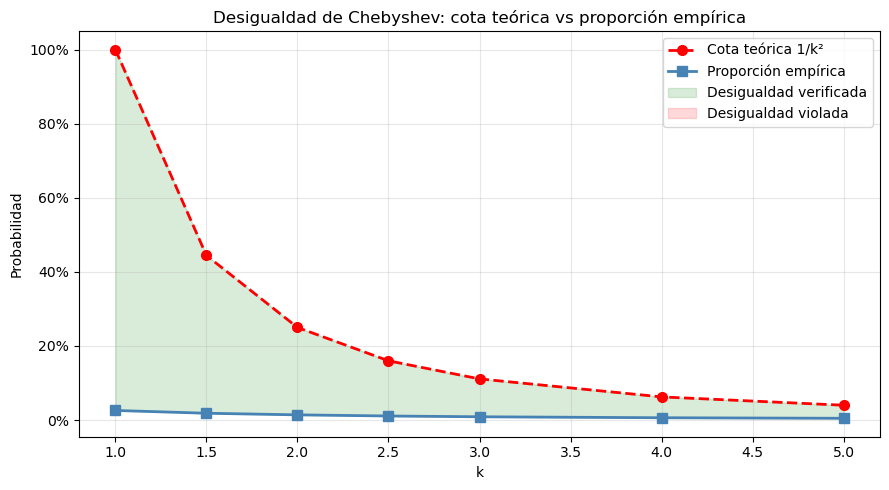

  PROPORCIÓN DE DATOS POR FRANJAS DE DESVIACIÓN ESTÁNDAR
Respecto a la MEDIA:
  0σ–1σ  : 97.4123%
  1σ–2σ  : 1.1857%
  2σ–3σ  : 0.5198%
  >3σ    : 0.8822%
---------------------------------------------------------------------------
Respecto a la MEDIANA:
  0σ–1σ  : 97.0717%
  1σ–2σ  : 1.4295%
  2σ–3σ  : 0.5578%
  >3σ    : 0.9410%


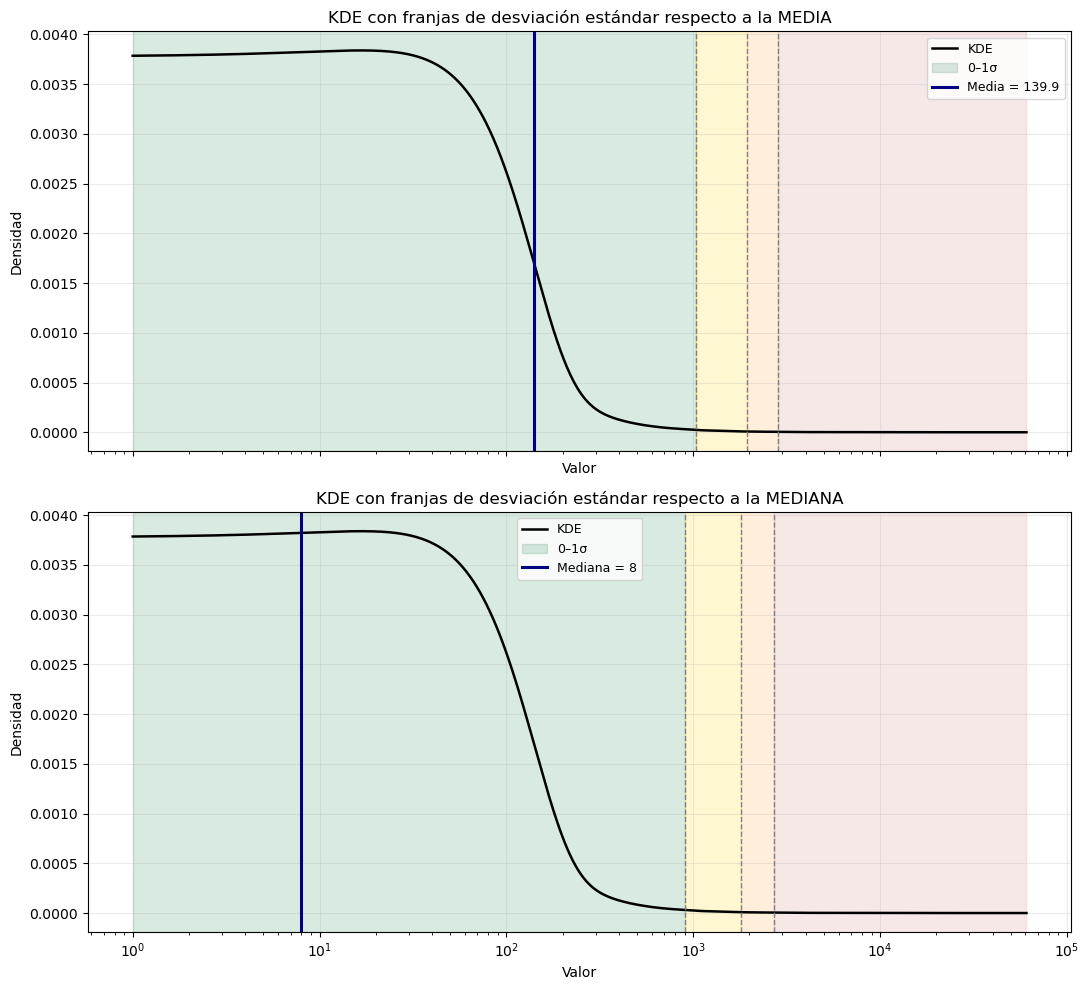

In [17]:
# =========================================
# 6) Desigualdad de Chebyshev + franjas KDE
#    respecto a la media y a la mediana
# =========================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

mu      = float(np.mean(data_kde))
mediana = float(np.median(data_kde))
sigma   = float(np.std(data_kde, ddof=1))

if sigma == 0:
    raise ValueError("La desviación estándar es 0; no se pueden construir franjas por sigma.")

ks = [1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]

# -------------------------------------------------
# A) Tabla clásica de Chebyshev (respecto a la media)
# -------------------------------------------------
print("=" * 75)
print("  DESIGUALDAD DE CHEBYSHEV")
print(f"  media = {mu:.6g}  |  mediana = {mediana:.6g}  |  sigma = {sigma:.6g}  |  N = {len(data_kde)}")
print("=" * 75)
print(f"  {'k':>5}  {'media ± k*sigma':>24}  {'Cota 1/k²':>12}  {'Prop. empírica':>16}  {'Cumple?':>8}")
print("-" * 75)

filas = []
for k in ks:
    cota_teorica   = 1.0 / k**2
    n_fuera        = int(np.sum(np.abs(data_kde - mu) >= k * sigma))
    prop_empirica  = n_fuera / len(data_kde)
    cumple         = prop_empirica <= cota_teorica
    lo, hi         = mu - k * sigma, mu + k * sigma
    intervalo      = f"[{lo:.4g}, {hi:.4g}]"
    print(f"  {k:>5.1f}  {intervalo:>24}  {cota_teorica:>12.6f}  {prop_empirica:>16.6f}  {'SI' if cumple else 'NO':>8}")
    filas.append(dict(
        k=k,
        cota_teorica=cota_teorica,
        prop_empirica=prop_empirica,
        cumple=cumple
    ))

print("=" * 75)
print("Nota: la desigualdad de Chebyshev formalmente se evalúa respecto a la MEDIA.")
print("La gráfica respecto a la MEDIANA es descriptiva/interpretativa, no la formulación clásica.")
print()

# -------------------------------------------------
# B) Gráfica clásica: cota teórica vs proporción empírica
# -------------------------------------------------
ks_arr    = np.array([f["k"]             for f in filas])
cotas     = np.array([f["cota_teorica"]  for f in filas])
empiricas = np.array([f["prop_empirica"] for f in filas])

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(ks_arr, cotas,     "o--", color="red",       linewidth=2, markersize=7, label="Cota teórica 1/k²")
ax.plot(ks_arr, empiricas, "s-",  color="steelblue", linewidth=2, markersize=7, label="Proporción empírica")

ax.fill_between(ks_arr, empiricas, cotas,
                where=(empiricas <= cotas),
                alpha=0.15, color="green", label="Desigualdad verificada")
ax.fill_between(ks_arr, empiricas, cotas,
                where=(empiricas > cotas),
                alpha=0.15, color="red", label="Desigualdad violada")

ax.set_xlabel("k")
ax.set_ylabel("Probabilidad")
ax.set_title("Desigualdad de Chebyshev: cota teórica vs proporción empírica")
ax.legend()
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------------------------
# C) Funciones auxiliares para franjas sobre la KDE
# -------------------------------------------------
def resumen_franjas(data, centro, sigma):
    z_abs = np.abs(data - centro) / sigma
    resumen = {
        "0σ–1σ":  np.mean(z_abs < 1),
        "1σ–2σ":  np.mean((z_abs >= 1) & (z_abs < 2)),
        "2σ–3σ":  np.mean((z_abs >= 2) & (z_abs < 3)),
        ">3σ":    np.mean(z_abs >= 3),
    }
    return resumen

def linea_vertical_segura(ax, x, usar_log, **kwargs):
    # En escala log no se deben dibujar líneas en x <= 0
    if usar_log and x <= 0:
        return
    ax.axvline(x, **kwargs)

def graficar_franjas_kde(ax, x_grid, y_grid, centro, sigma, titulo, etiqueta_centro, usar_log=False):
    # KDE base
    ax.plot(x_grid, y_grid, color="black", linewidth=1.8, label="KDE")

    # Límites de franjas
    a1, b1 = centro - 1*sigma, centro + 1*sigma
    a2, b2 = centro - 2*sigma, centro + 2*sigma
    a3, b3 = centro - 3*sigma, centro + 3*sigma

    xmin = np.min(x_grid)
    xmax = np.max(x_grid)

    # Ajustar si hay escala log (no se puede graficar <= 0)
    if usar_log:
        xmin = max(xmin, 1e-12)

    # Función auxiliar para recortar al rango visible
    def clip(lo, hi):
        lo = max(lo, xmin)
        hi = min(hi, xmax)
        return lo, hi

    # >3σ izquierda
    lo, hi = clip(xmin, a3)
    if hi > lo:
        ax.axvspan(lo, hi, color="firebrick", alpha=0.10, label=">3σ")

    # 2σ–3σ izquierda
    lo, hi = clip(a3, a2)
    if hi > lo:
        ax.axvspan(lo, hi, color="darkorange", alpha=0.14, label="2–3σ")

    # 1σ–2σ izquierda
    lo, hi = clip(a2, a1)
    if hi > lo:
        ax.axvspan(lo, hi, color="gold", alpha=0.18, label="1–2σ")

    # 0σ–1σ centro
    lo, hi = clip(a1, b1)
    if hi > lo:
        ax.axvspan(lo, hi, color="seagreen", alpha=0.18, label="0–1σ")

    # 1σ–2σ derecha
    lo, hi = clip(b1, b2)
    if hi > lo:
        ax.axvspan(lo, hi, color="gold", alpha=0.18)

    # 2σ–3σ derecha
    lo, hi = clip(b2, b3)
    if hi > lo:
        ax.axvspan(lo, hi, color="darkorange", alpha=0.14)

    # >3σ derecha
    lo, hi = clip(b3, xmax)
    if hi > lo:
        ax.axvspan(lo, hi, color="firebrick", alpha=0.10)

    # Línea central
    if not (usar_log and centro <= 0):
        ax.axvline(centro, color="navy", linestyle="-", linewidth=2.2,
                   label=f"{etiqueta_centro} = {centro:.4g}")

    # Líneas de ±1σ, ±2σ, ±3σ
    for k in [1, 2, 3]:
        left = centro - k*sigma
        right = centro + k*sigma

        if not (usar_log and left <= 0):
            ax.axvline(left, color="gray", linestyle="--", linewidth=1.0)
        if not (usar_log and right <= 0):
            ax.axvline(right, color="gray", linestyle="--", linewidth=1.0)

    if usar_log:
        ax.set_xscale("log")

    ax.set_title(titulo)
    ax.set_xlabel("Valor")
    ax.set_ylabel("Densidad")
    ax.grid(True, alpha=0.25)

    # evitar etiquetas duplicadas
    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    handles2, labels2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            handles2.append(h)
            labels2.append(l)
            seen.add(l)
    ax.legend(handles2, labels2, fontsize=9)
# -------------------------------------------------
# D) Resumen numérico de franjas
# -------------------------------------------------
res_media   = resumen_franjas(data_kde, mu, sigma)
res_mediana = resumen_franjas(data_kde, mediana, sigma)

print("=" * 75)
print("  PROPORCIÓN DE DATOS POR FRANJAS DE DESVIACIÓN ESTÁNDAR")
print("=" * 75)

print("Respecto a la MEDIA:")
for etiqueta, prop in res_media.items():
    print(f"  {etiqueta:<6} : {prop:.4%}")

print("-" * 75)

print("Respecto a la MEDIANA:")
for etiqueta, prop in res_mediana.items():
    print(f"  {etiqueta:<6} : {prop:.4%}")

print("=" * 75)

# -------------------------------------------------
# E) Dos gráficas pedidas: media y mediana
# -------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(11, 10), sharex=True)

graficar_franjas_kde(
    axes[0],
    x_grid, y_grid,
    centro=mu,
    sigma=sigma,
    titulo="KDE con franjas de desviación estándar respecto a la MEDIA",
    etiqueta_centro="Media",
    usar_log=usar_escala_log_x
)

graficar_franjas_kde(
    axes[1],
    x_grid, y_grid,
    centro=mediana,
    sigma=sigma,
    titulo="KDE con franjas de desviación estándar respecto a la MEDIANA",
    etiqueta_centro="Mediana",
    usar_log=usar_escala_log_x
)

plt.tight_layout()
plt.show()

## 7) Grupos Naturales Emergentes del KDE

El propio KDE revela **grupos naturales** en la distribución: zonas de alta densidad separadas por valles (mínimos locales).

**Método:**
- Se detectan los **picos locales** (modas) del KDE con `scipy.signal.find_peaks`.
- Los **valles entre picos consecutivos** actúan como fronteras naturales entre grupos.
- Se reportan estadísticas de cada grupo para preparar el terreno al clustering formal.

  GRUPOS NATURALES DEL KDE  (1 modo(s) detectado(s))
  Parámetros: prominence ≥ 0.0001919  |  distance ≥ 200 puntos

  Grupo 1:
    Rango     : [1,  6.071e+04]
    Pico KDE  : x = 16.57  (densidad = 0.003838)
    N puntos  : 105420  (100.0% del total)
    Media     : 139.9
    Mediana   : 8
    Std       : 895.1



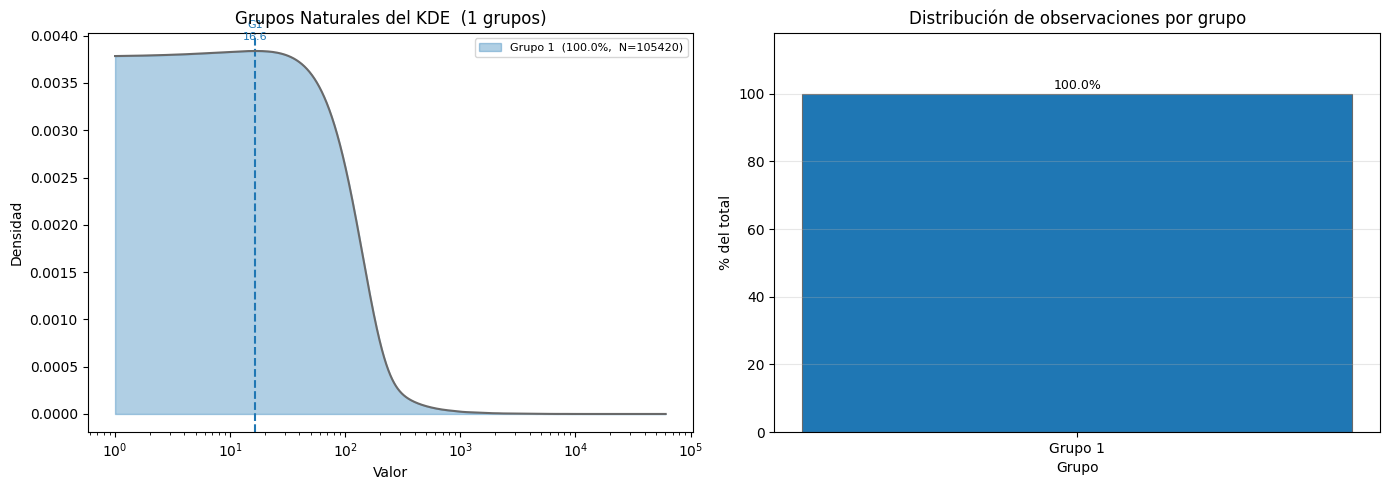

In [9]:
# =========================================
# 7) Grupos Naturales Emergentes del KDE
# =========================================
from scipy.signal import find_peaks

# -----------------------------
# Parámetros de detección de picos
# -----------------------------
prominence_frac = 0.05   # mínima prominencia como fracción del pico máximo
distance_frac   = 0.02   # mínima separación entre picos (fracción del total de puntos)

prom_min = prominence_frac * y_grid.max()
dist_min = max(1, int(distance_frac * len(x_grid)))

picos_idx, _ = find_peaks(y_grid, prominence=prom_min, distance=dist_min)

if len(picos_idx) == 0:
    picos_idx = np.array([np.argmax(y_grid)])

n_grupos = len(picos_idx)

print("=" * 60)
print(f"  GRUPOS NATURALES DEL KDE  ({n_grupos} modo(s) detectado(s))")
print("=" * 60)
print(f"  Parámetros: prominence ≥ {prom_min:.4g}  |  distance ≥ {dist_min} puntos")
print()

# -----------------------------
# Fronteras: valle entre picos consecutivos
# -----------------------------
fronteras = []
for i in range(len(picos_idx) - 1):
    seg_y = y_grid[picos_idx[i]:picos_idx[i + 1]]
    seg_x = x_grid[picos_idx[i]:picos_idx[i + 1]]
    fronteras.append(float(seg_x[np.argmin(seg_y)]))

limites = [float(x_grid[0])] + fronteras + [float(x_grid[-1])]

# -----------------------------
# Estadísticas por grupo
# -----------------------------
grupos_info = []
for i in range(n_grupos):
    lo, hi = limites[i], limites[i + 1]
    mask = (data_kde >= lo) & (data_kde <= hi)
    datos_g = data_kde[mask]

    grupos_info.append({
        "grupo"  : i + 1,
        "x_peak" : float(x_grid[picos_idx[i]]),
        "y_peak" : float(y_grid[picos_idx[i]]),
        "x_lo"   : lo,
        "x_hi"   : hi,
        "n"      : len(datos_g),
        "pct"    : 100.0 * len(datos_g) / len(data_kde),
        "media"  : float(np.mean(datos_g))           if len(datos_g) > 0 else np.nan,
        "mediana": float(np.median(datos_g))         if len(datos_g) > 0 else np.nan,
        "std"    : float(np.std(datos_g, ddof=1))    if len(datos_g) > 1 else np.nan,
    })

    g = grupos_info[-1]
    print(f"  Grupo {g['grupo']}:")
    print(f"    Rango     : [{g['x_lo']:.4g},  {g['x_hi']:.4g}]")
    print(f"    Pico KDE  : x = {g['x_peak']:.4g}  (densidad = {g['y_peak']:.4g})")
    print(f"    N puntos  : {g['n']}  ({g['pct']:.1f}% del total)")
    print(f"    Media     : {g['media']:.4g}")
    print(f"    Mediana   : {g['mediana']:.4g}")
    print(f"    Std       : {g['std']:.4g}")
    if i < n_grupos - 1:
        print(f"    Frontera  → {fronteras[i]:.4g}  (valle hacia grupo {i + 2})")
    print()

print("=" * 60)

# -----------------------------
# Visualización
# -----------------------------
colores_g = plt.cm.tab10(np.linspace(0, 0.9, n_grupos))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: KDE sombreado por grupos
ax = axes[0]
for i, g in enumerate(grupos_info):
    mask_plot = (x_grid >= g["x_lo"]) & (x_grid <= g["x_hi"])
    ax.fill_between(x_grid, y_grid, where=mask_plot,
                    alpha=0.35, color=colores_g[i],
                    label=f"Grupo {g['grupo']}  ({g['pct']:.1f}%,  N={g['n']})")
    ax.axvline(g["x_peak"], color=colores_g[i], linestyle="--", linewidth=1.5)
    ax.annotate(f"G{g['grupo']}\n{g['x_peak']:.3g}",
                xy=(g["x_peak"], g["y_peak"]),
                xytext=(0, 8), textcoords="offset points",
                ha="center", fontsize=8, color=colores_g[i])

for xf in fronteras:
    ax.axvline(xf, color="black", linestyle=":", linewidth=1.2, alpha=0.7,
               label=f"Valle: {xf:.3g}" if xf == fronteras[0] else "_nolegend_")

ax.plot(x_grid, y_grid, linewidth=1.5, color="dimgray")

if usar_escala_log_x:
    ax.set_xscale("log")
ax.set_title(f"Grupos Naturales del KDE  ({n_grupos} grupos)")
ax.set_xlabel("Valor")
ax.set_ylabel("Densidad")
ax.legend(fontsize=8, loc="upper right")

# Panel derecho: % de datos por grupo (barras)
ax2 = axes[1]
labels_g = [f"Grupo {g['grupo']}" for g in grupos_info]
pcts     = [g["pct"] for g in grupos_info]
bars = ax2.bar(labels_g, pcts, color=colores_g, edgecolor="dimgray", linewidth=0.8)
for bar, pct in zip(bars, pcts):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
             f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

ax2.set_title("Distribución de observaciones por grupo")
ax2.set_xlabel("Grupo")
ax2.set_ylabel("% del total")
ax2.set_ylim(0, max(pcts) * 1.18)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()